<a href="https://colab.research.google.com/github/NadiiaIvashchuk/melbourne-housing-project/blob/main/notebooks/melbourne_housing_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Melbourne Housing Project

## Data preparation

In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_curve, auc
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer          # заповнення пропусків
from sklearn.preprocessing import OneHotEncoder   # кодування категорій
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

FILE_IN = 'https://raw.githubusercontent.com/NadiiaIvashchuk/melbourne-housing-project/refs/heads/main/data/melb_data.csv'
df_origin = pd.read_csv(FILE_IN)
df = df_origin.copy()

print("Ринок нерухомості в Мельбурні:", df.shape)
df.head()

Ринок нерухомості в Мельбурні: (13580, 21)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [97]:
pd.read_csv('https://raw.githubusercontent.com/NadiiaIvashchuk/melbourne-housing-project/refs/heads/main/data/melb_data.csv')

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,4/03/2017,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.79690,144.99690,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,4/06/2016,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.80720,144.99410,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13575,Wheelers Hill,12 Strada Cr,4,h,1245000.0,S,Barry,26/08/2017,16.7,3150.0,4.0,2.0,2.0,652.0,NaN,1981.0,NaN,-37.90562,145.16761,South-Eastern Metropolitan,7392.0
13576,Williamstown,77 Merrett Dr,3,h,1031000.0,SP,Williams,26/08/2017,6.8,3016.0,3.0,2.0,2.0,333.0,133.0,1995.0,NaN,-37.85927,144.87904,Western Metropolitan,6380.0
13577,Williamstown,83 Power St,3,h,1170000.0,S,Raine,26/08/2017,6.8,3016.0,3.0,2.0,4.0,436.0,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380.0
13578,Williamstown,96 Verdon St,4,h,2500000.0,PI,Sweeney,26/08/2017,6.8,3016.0,4.0,1.0,5.0,866.0,157.0,1920.0,NaN,-37.85908,144.89299,Western Metropolitan,6380.0


## First review of data set

In [98]:
#Data types
df.dtypes

,0
Suburb,object
Address,object
Rooms,int64
Type,object
Price,float64
Method,object
SellerG,object
Date,object
Distance,float64
Postcode,float64


In [99]:
#Missing values
print("Missing values:\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,%
Car,62,0.5
BuildingArea,6450,47.5
YearBuilt,5375,39.6
CouncilArea,1369,10.1


In [100]:
#Min, average, max, std, percentiles
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,13580.000000,1.358000e+04,13580.000000,13580.000000,13580.000000,13580.000000,13518.000000,13580.000000,7130.000000,8205.000000,13580.000000,13580.000000,13580.000000
mean,2.937997,1.075684e+06,10.137776,3105.301915,2.914728,1.534242,1.610075,558.416127,151.967650,1964.684217,-37.809203,144.995216,7454.417378
std,0.955748,6.393107e+05,5.868725,90.676964,0.965921,0.691712,0.962634,3990.669241,541.014538,37.273762,0.079260,0.103916,4378.581772
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1196.000000,-38.182550,144.431810,249.000000
25%,2.000000,6.500000e+05,6.100000,3044.000000,2.000000,1.000000,1.000000,177.000000,93.000000,1940.000000,-37.856822,144.929600,4380.000000
50%,3.000000,9.030000e+05,9.200000,3084.000000,3.000000,1.000000,2.000000,440.000000,126.000000,1970.000000,-37.802355,145.000100,6555.000000
75%,3.000000,1.330000e+06,13.000000,3148.000000,3.000000,2.000000,2.000000,651.000000,174.000000,1999.000000,-37.756400,145.058305,10331.000000
max,10.000000,9.000000e+06,48.100000,3977.000000,20.000000,8.000000,10.000000,433014.000000,44515.000000,2018.000000,-37.408530,145.526350,21650.000000


## Cleaning

In [101]:
clean = df.copy() # copy dataframe for cleaning
clean.columns = clean.columns.str.strip() # remove spaces in column names

#rename columns
clean = clean.rename(columns={
    'Suburb': 'suburb',
    'Address': 'address',
    'Rooms': 'cnt_rooms',
    'Type': 'type',
    'Price': 'price',
    'Method': 'method',
    'SellerG': 'seller',
    'Date': 'date',
    'Distance': 'distance',
    'Postcode': 'postcode',
    'Bedroom2': 'bedroom',
    'Bathroom': 'bathroom',
    'Car': 'cnt_carpots',
    'Landsize': 'landsize',
    'BuildingArea': 'build_area',
    'YearBuilt': 'year_built',
    'CouncilArea': 'gov_area',
    'Lattitude': 'lattitude',
    'Longtitude': 'longtitude',
    'Regionname': 'region',
    'Propertycount': 'propertycount'
})


# date to datetime type
clean['date'] = pd.to_datetime(clean['date'], dayfirst=True, errors='coerce')

clean.head()


,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [102]:
# year_built > date -> NaN
incor_built_year = clean.loc[clean['year_built'] > clean['date'].dt.year]
display(incor_built_year)
print(f"Data where year_built > date of deal: {(clean['year_built'] > clean['date'].dt.year).sum()} rows -> replace to NaN")

clean.loc[clean['year_built'] > clean['date'].dt.year, 'year_built']= np.nan



,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
441,Avondale Heights,157 Canning St,3,t,851000.0,S,Nelson,2016-12-03,10.5,3034.0,3.0,3.0,1.0,557.0,181.0,2017.0,Moonee Valley,-37.7700,144.8572,Western Metropolitan,4502.0
1234,Brighton East,8 Thomas St,2,h,1310000.0,S,Buxton,2016-09-24,10.7,3187.0,4.0,3.0,2.0,302.0,250.0,2018.0,Glen Eira,-37.9182,145.0231,Southern Metropolitan,6938.0
3489,Keilor East,20 Keith Gr,3,h,825000.0,S,Nelson,2016-04-23,12.8,3033.0,3.0,2.0,1.0,630.0,126.0,2017.0,Moonee Valley,-37.7378,144.8705,Western Metropolitan,5629.0
4282,Newport,7 Durkin St,3,h,945000.0,S,Jas,2016-05-28,8.4,3015.0,4.0,2.0,1.0,487.0,190.0,2017.0,Hobsons Bay,-37.8438,144.8806,Western Metropolitan,5498.0
5153,Reservoir,89 Darebin Bvd,4,h,767500.0,S,Barry,2016-09-17,11.2,3073.0,3.0,2.0,2.0,834.0,129.0,2017.0,Darebin,-37.7040,145.0299,Northern Metropolitan,21650.0
7060,Heidelberg,36 Buckingham Dr,3,h,1030000.0,S,Miles,2016-07-30,10.6,3084.0,5.0,3.0,2.0,649.0,357.0,2017.0,Banyule,-37.7501,145.0822,Eastern Metropolitan,2890.0


Data where year_built > date of deal: 6 rows -> replace to NaN


In [103]:
# built_area, landsize == 0
print(f"Rows with '0' value for landsize: {(clean['landsize']==0).sum()} -> replace to NaN")
print(f"Rows with '0' value for build_area: {(clean['build_area']==0).sum()} -> replace to NaN")
print(f"Rows with '0' value for cnt_carpots: {(clean['cnt_carpots']==0).sum()} -> replace to NaN")

for col in ['landsize', 'build_area']:
  clean.loc[clean[col] == 0, col] = np.nan


Rows with '0' value for landsize: 1939 -> replace to NaN
Rows with '0' value for build_area: 17 -> replace to NaN
Rows with '0' value for cnt_carpots: 1026 -> replace to NaN


In [104]:
print(f"Rows with '0' value for landsize: {(clean['landsize']==0).sum()} -> replace to NaN")
print(f"Rows with '0' value for build_area: {(clean['build_area']==0).sum()} -> replace to NaN")
print(f"Rows with '0' value for cnt_carpots: {(clean['cnt_carpots']==0).sum()} -> replace to NaN")

Rows with '0' value for landsize: 0 -> replace to NaN
Rows with '0' value for build_area: 0 -> replace to NaN
Rows with '0' value for cnt_carpots: 1026 -> replace to NaN


In [105]:
clean.head()

,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067.0,2.0,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067.0,3.0,2.0,1.0,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0


In [106]:
# Check of the year of building

#Find unique value 'year_built'
display(clean['year_built'].sort_values().head(10))

#IQR
Q1 = clean['year_built'].quantile(0.25)
Q3 = clean['year_built'].quantile(0.75)
IQR = Q3 - Q1
reason_limit = Q1 - 1.5 * IQR
print(f"Reasonable limit for 'year_built': {reason_limit.astype(int)}")

# to Nan
print(f"Count rows with year_built < 1850: {(clean['year_built'] < 1850).sum()} rows -> to NaN") # I save 1850 because count rows with this value > 2 and this in line with the subject area
clean.loc[clean['year_built'] < 1850, 'year_built'] = np.nan


,year_built
9968,1196.0
2079,1830.0
2554,1850.0
5405,1850.0
4843,1850.0
5860,1850.0
2530,1854.0
5536,1856.0
12158,1857.0
5543,1860.0


Reasonable limit for 'year_built': 1851
Count rows with year_built < 1850: 2 rows -> to NaN


In [107]:
#check duplicate
print(f"Count of duplicates: {clean.duplicated().sum()}")

Count of duplicates: 0


In [108]:
#research rows with 'na' value in build_area
build_na = clean[clean['build_area'].isna()]
fill_rows_rate = build_na.notna().mean().sort_values(ascending=False).to_frame('fill_rows_rate')
fill_rows_rate['fill_percent'] = fill_rows_rate['fill_rows_rate'] * 100

fill_rows_rate  # видаляти рядки недоцільно

,fill_rows_rate,fill_percent
suburb,1.000000,100.000000
address,1.000000,100.000000
cnt_rooms,1.000000,100.000000
type,1.000000,100.000000
price,1.000000,100.000000
method,1.000000,100.000000
seller,1.000000,100.000000
date,1.000000,100.000000
distance,1.000000,100.000000
postcode,1.000000,100.000000


In [109]:
#Build area(Null) & suburb
clean.groupby(clean['build_area'].isna())['suburb'].describe()

,count,unique,top,freq
build_area,,,,
False,7113,303,Reservoir,174
True,6467,294,Reservoir,185


In [110]:
# Build area(Null) & date
clean.groupby(clean['build_area'].isna())['date'].describe()

,count,mean,min,25%,50%,75%,max
build_area,,,,,,,
False,7113,2017-01-16 14:53:48.005061120,2016-02-04 00:00:00,2016-09-03 00:00:00,2016-12-10 00:00:00,2017-06-17 00:00:00,2017-09-23 00:00:00
True,6467,2017-02-11 07:15:32.426163712,2016-01-28 00:00:00,2016-09-17 00:00:00,2017-03-18 00:00:00,2017-07-01 00:00:00,2017-09-23 00:00:00


In [111]:
#Build area(Null) & type of building
clean.groupby(clean['build_area'].isna())['type'].value_counts()

build_area  type
False       h       4846
            u       1584
            t        683
True        h       4603
            u       1433
            t        431
Name: count, dtype: int64

In [112]:
print("""
Short conclusion about build_area (part 1):
A gap analysis was performed for the build_area column.
It was found that records with missing values ​​contained almost the full set of other characteristics.
Additionally, the distributions of price, landsize, type, suburb, and sale date (date) were compared
between records with and without build_area. No significant differences were found, so the gaps
do not show an obvious systematic pattern. At the data cleaning stage, it was decided not to delete these rows
""")


Short conclusion about build_area (part 1):
A gap analysis was performed for the build_area column.  
It was found that records with missing values ​​contained almost the full set of other characteristics.  
Additionally, the distributions of price, landsize, type, suburb, and sale date (date) were compared  
between records with and without build_area. No significant differences were found, so the gaps  
do not show an obvious systematic pattern. At the data cleaning stage, it was decided not to delete these rows



In [113]:
#Check build_area with small area
# build_area < 10 m2
mask_1 = clean[clean['build_area'] < 10]
display(mask_1)
print(f"\nCount rows with built area < 10: {len(mask_1)}")

# build_area < 10 m2 & count rooms > 1
mask_2 = clean[(clean['build_area'] < 10) & (clean['cnt_rooms'] > 1)]
display(mask_2)
print(f"\nCount rows with built area < 10: {len(mask_2)}")

# build_area < 10 m2 & count rooms <= 1
mask_3 = clean[(clean['build_area'] < 10) & (clean['cnt_rooms'] <= 1)]
display(mask_3)

print(f"Count rows with build_area < 10 & count of rooms > 1: {len(mask_2)} rows -> to NaN")
clean.loc[(clean['build_area'] < 10) & (clean['cnt_rooms'] > 1), 'year_built'] = np.nan # replace 'build_area' with mask_2

,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
181,Altona,5/57 Blyth St,3,u,730000.0,SP,Barlow,2016-05-28,13.8,3018.0,3.0,2.0,1.0,70.0,3.0,2014.0,Hobsons Bay,-37.86800,144.82850,Western Metropolitan,5301.0
274,Armadale,3/769 High St,3,t,1101000.0,S,Jellis,2016-11-27,6.3,3143.0,3.0,1.0,2.0,103.0,3.0,2000.0,Stonnington,-37.85420,145.01350,Southern Metropolitan,4836.0
663,Balwyn North,1 Morris St,6,h,1900000.0,VB,hockingstuart,2016-05-22,9.2,3104.0,6.0,1.0,6.0,691.0,5.0,NaN,Boroondara,-37.80220,145.07750,Southern Metropolitan,7809.0
984,Box Hill,3/14 Bedford St,3,t,750000.0,S,Jellis,2016-10-15,13.1,3128.0,3.0,2.0,1.0,150.0,3.0,2000.0,Whitehorse,-37.82870,145.13190,Eastern Metropolitan,4605.0
1138,Brighton,147A Male St,2,t,1037000.0,S,Buxton,2017-02-25,11.2,3186.0,2.0,1.0,2.0,125.0,2.0,2009.0,Bayside,-37.90780,145.00510,Southern Metropolitan,10579.0
1241,Brighton East,2/21 Hodder St,4,t,1367000.0,S,McGrath,2016-07-26,10.7,3187.0,4.0,2.0,2.0,315.0,4.0,2000.0,Bayside,-37.90780,145.02220,Southern Metropolitan,6938.0
1285,Brunswick,7/117 Albion St,2,t,620000.0,S,Harrington,2016-12-10,5.2,3056.0,2.0,2.0,1.0,72.0,2.0,NaN,Moreland,-37.76090,144.96900,Northern Metropolitan,11918.0
1371,Brunswick,329 Brunswick Rd,4,h,1175000.0,PI,Jellis,2016-11-27,5.2,3056.0,4.0,1.0,2.0,319.0,1.0,NaN,Moreland,-37.77630,144.95490,Northern Metropolitan,11918.0
1765,Carnegie,2 Poplar Gr,2,h,907000.0,S,Ray,2016-11-19,11.4,3163.0,2.0,1.0,2.0,316.0,2.0,NaN,Glen Eira,-37.88540,145.06360,Southern Metropolitan,7822.0
2029,Coburg,40 Elizabeth St,1,h,1007000.0,SP,Brad,2016-08-28,7.8,3058.0,1.0,2.0,0.0,807.0,1.0,NaN,Moreland,-37.73730,144.98250,Northern Metropolitan,11204.0



Count rows with built area < 10: 56


,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
181,Altona,5/57 Blyth St,3,u,730000.0,SP,Barlow,2016-05-28,13.8,3018.0,3.0,2.0,1.0,70.0,3.0,2014.0,Hobsons Bay,-37.86800,144.82850,Western Metropolitan,5301.0
274,Armadale,3/769 High St,3,t,1101000.0,S,Jellis,2016-11-27,6.3,3143.0,3.0,1.0,2.0,103.0,3.0,2000.0,Stonnington,-37.85420,145.01350,Southern Metropolitan,4836.0
663,Balwyn North,1 Morris St,6,h,1900000.0,VB,hockingstuart,2016-05-22,9.2,3104.0,6.0,1.0,6.0,691.0,5.0,NaN,Boroondara,-37.80220,145.07750,Southern Metropolitan,7809.0
984,Box Hill,3/14 Bedford St,3,t,750000.0,S,Jellis,2016-10-15,13.1,3128.0,3.0,2.0,1.0,150.0,3.0,2000.0,Whitehorse,-37.82870,145.13190,Eastern Metropolitan,4605.0
1138,Brighton,147A Male St,2,t,1037000.0,S,Buxton,2017-02-25,11.2,3186.0,2.0,1.0,2.0,125.0,2.0,2009.0,Bayside,-37.90780,145.00510,Southern Metropolitan,10579.0
1241,Brighton East,2/21 Hodder St,4,t,1367000.0,S,McGrath,2016-07-26,10.7,3187.0,4.0,2.0,2.0,315.0,4.0,2000.0,Bayside,-37.90780,145.02220,Southern Metropolitan,6938.0
1285,Brunswick,7/117 Albion St,2,t,620000.0,S,Harrington,2016-12-10,5.2,3056.0,2.0,2.0,1.0,72.0,2.0,NaN,Moreland,-37.76090,144.96900,Northern Metropolitan,11918.0
1371,Brunswick,329 Brunswick Rd,4,h,1175000.0,PI,Jellis,2016-11-27,5.2,3056.0,4.0,1.0,2.0,319.0,1.0,NaN,Moreland,-37.77630,144.95490,Northern Metropolitan,11918.0
1765,Carnegie,2 Poplar Gr,2,h,907000.0,S,Ray,2016-11-19,11.4,3163.0,2.0,1.0,2.0,316.0,2.0,NaN,Glen Eira,-37.88540,145.06360,Southern Metropolitan,7822.0
2117,Collingwood,12/120 Cambridge St,2,u,1645000.0,S,Nelson,2016-05-28,1.6,3066.0,4.0,1.0,3.0,NaN,2.0,1890.0,Yarra,-37.80460,144.98580,Northern Metropolitan,4553.0



Count rows with built area < 10: 53


,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
2029,Coburg,40 Elizabeth St,1,h,1007000.0,SP,Brad,2016-08-28,7.8,3058.0,1.0,2.0,0.0,807.0,1.0,NaN,Moreland,-37.7373,144.9825,Northern Metropolitan,11204.0
5306,Richmond,5/285 Punt Rd,1,u,342000.0,S,Jellis,2016-09-10,2.6,3121.0,1.0,1.0,1.0,NaN,1.0,1970.0,Yarra,-37.8214,144.9896,Northern Metropolitan,14949.0
6398,Toorak,16/36 Grange Rd,1,u,460000.0,PI,hockingstuart,2016-07-26,4.6,3142.0,1.0,1.0,1.0,NaN,7.0,NaN,Stonnington,-37.8373,145.0116,Southern Metropolitan,7217.0


Count rows with build_area < 10 & count of rooms > 1: 53 rows -> to NaN


In [114]:
print("""
Short conclusion about build_area (part2):
The analysis revealed 52 rows where the building area does not exceed 10 m²,
although the number of rooms is more than 1, and the landsize often exceeds 100 m². Such records
appear anomalous and are likely the result of data entry or collection errors. Therefore,
these values ​​were replaced with NaN
""")


Short conclusion about build_area (part2):
The analysis revealed 52 rows where the building area does not exceed 10 m²,  
although the number of rooms is more than 1, and the landsize often exceeds 100 m². Such records  
appear anomalous and are likely the result of data entry or collection errors. Therefore,  
these values ​​were replaced with NaN



In [115]:
# logical consistency check
print("Count bedroom > count rooms:")
display(clean[clean['bedroom'] > clean['cnt_rooms']])

print("Count bathroom > count rooms:")
display(clean[clean['bathroom'] > clean['cnt_rooms']])



Count bedroom > count rooms:


,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
6,Abbotsford,124 Yarra St,3,h,1876000.0,S,Nelson,2016-05-07,2.5,3067.0,4.0,2.0,0.0,245.0,210.0,1910.0,Yarra,-37.80240,144.99930,Northern Metropolitan,4019.0
9,Abbotsford,10 Valiant St,2,h,1097000.0,S,Biggin,2016-10-08,2.5,3067.0,3.0,1.0,2.0,220.0,75.0,1900.0,Yarra,-37.80100,144.99890,Northern Metropolitan,4019.0
63,Airport West,6 Kittyhawk St,4,h,773000.0,S,Brad,2016-09-17,13.5,3042.0,5.0,3.0,4.0,531.0,309.0,1980.0,Moonee Valley,-37.72630,144.86790,Western Metropolitan,3464.0
207,Altona North,1/156 Chambers Rd,3,h,620000.0,SP,Hunter,2016-08-22,11.1,3025.0,5.0,2.0,2.0,276.0,100.0,2010.0,Hobsons Bay,-37.82620,144.84430,Western Metropolitan,5132.0
233,Armadale,11/17 Myamyn St,2,u,3625000.0,S,Jellis,2016-06-04,6.3,3143.0,3.0,2.0,2.0,NaN,NaN,2006.0,Stonnington,-37.85550,145.02910,Southern Metropolitan,4836.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11536,Watsonia North,280 Grimshaw St,3,h,740000.0,SP,Barry,2017-07-15,14.5,3087.0,4.0,1.0,2.0,909.0,NaN,NaN,Banyule,-37.70255,145.08578,Northern Metropolitan,1442.0
11579,Aspendale,14 Ebb St,3,h,970000.0,VB,hockingstuart,2017-07-22,21.5,3195.0,4.0,2.0,2.0,612.0,154.0,1960.0,Kingston,-38.01596,145.09932,South-Eastern Metropolitan,2824.0
11846,Toorak,10/270 Williams Rd,1,u,350000.0,VB,Marshall,2017-07-22,4.1,3142.0,2.0,1.0,1.0,NaN,NaN,1970.0,Stonnington,-37.84157,145.00469,Southern Metropolitan,7217.0
12411,Thornbury,316 Rossmoyne St,3,h,1375000.0,S,McGrath,2017-09-03,7.0,3071.0,4.0,2.0,3.0,530.0,145.0,1950.0,NaN,-37.75968,145.02305,Northern Metropolitan,8870.0


Count bathroom > count rooms:


,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
240,Armadale,10 William St,1,h,1435000.0,SP,Jellis,2016-10-08,6.3,3143.0,2.0,2.0,1.0,144.0,107.0,1900.0,Stonnington,-37.85640,145.02280,Southern Metropolitan,4836.0
446,Avondale Heights,6 Lovett Dr,4,h,1200000.0,S,Nelson,2016-06-04,10.5,3034.0,4.0,5.0,4.0,673.0,NaN,NaN,Moonee Valley,-37.75450,144.87360,Western Metropolitan,4502.0
557,Balwyn,49 Metung St,5,h,3400000.0,VB,Jellis,2016-06-18,9.7,3103.0,5.0,6.0,4.0,739.0,502.0,NaN,Boroondara,-37.80390,145.07140,Southern Metropolitan,5682.0
580,Balwyn,29 Sevenoaks St,5,h,3900000.0,PI,Jellis,2016-08-28,9.7,3103.0,5.0,7.0,6.0,NaN,NaN,NaN,Boroondara,-37.80490,145.07480,Southern Metropolitan,5682.0
1115,Brighton,89 South Rd,3,h,2020000.0,S,Nick,2016-09-17,11.2,3186.0,5.0,6.0,2.0,685.0,419.0,NaN,Bayside,-37.92840,144.99860,Southern Metropolitan,10579.0
1184,Brighton East,5 Margaret St,2,h,1780000.0,SP,Buxton,2016-05-07,10.7,3187.0,4.0,3.0,2.0,635.0,119.0,1935.0,Bayside,-37.92050,145.01020,Southern Metropolitan,6938.0
1234,Brighton East,8 Thomas St,2,h,1310000.0,S,Buxton,2016-09-24,10.7,3187.0,4.0,3.0,2.0,302.0,250.0,NaN,Glen Eira,-37.91820,145.02310,Southern Metropolitan,6938.0
2029,Coburg,40 Elizabeth St,1,h,1007000.0,SP,Brad,2016-08-28,7.8,3058.0,1.0,2.0,0.0,807.0,1.0,NaN,Moreland,-37.73730,144.98250,Northern Metropolitan,11204.0
2560,Fitzroy North,186 Queens Pde,2,t,930000.0,S,Nelson,2016-09-03,3.5,3068.0,2.0,3.0,0.0,2778.0,3558.0,NaN,Yarra,-37.79030,144.98590,Northern Metropolitan,6244.0
2992,Hadfield,101 Middle St,2,h,722000.0,S,Stockdale,2016-08-13,12.1,3046.0,3.0,3.0,1.0,580.0,103.0,1950.0,Moreland,-37.70980,144.94240,Northern Metropolitan,2606.0


In [116]:
clean = clean[
    (clean['bedroom'] <= clean['cnt_rooms']) &
     (clean['bathroom'] <= clean['cnt_rooms'])
].reset_index(drop=True)


Logical consistency check. Було виявлено 222 записи, у яких кількість спалень або ванних кімнат перевищувала загальну кількість кімнат (cnt_rooms). Такі записи суперечать логіці, тому були видалені з датасета.

In [117]:
# check coordinate
clean[['lattitude', 'longtitude']].describe()

,lattitude,longtitude
count,13358.000000,13358.000000
mean,-37.809079,144.995109
std,0.079440,0.104256
min,-38.182550,144.431810
25%,-37.856815,144.929200
50%,-37.802200,145.000000
75%,-37.756125,145.058315
max,-37.408530,145.526350


In [118]:
int_columns = ['cnt_rooms', 'postcode', 'bedroom', 'bathroom', 'cnt_carpots', 'year_built', 'propertycount']
clean[int_columns] = clean[int_columns].astype('Int64')

clean.head()

,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2016-12-03,2.5,3067,2,1,1,202.0,NaN,<NA>,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2016-02-04,2.5,3067,2,1,0,156.0,79.0,1900,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2017-03-04,2.5,3067,3,2,0,134.0,150.0,1900,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2017-03-04,2.5,3067,3,2,1,94.0,NaN,<NA>,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2016-06-04,2.5,3067,3,1,2,120.0,142.0,2014,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


In [119]:
# convert price to thousends of AUD for easier onterpretation
clean['price'] = clean['price'] / 1000

In [120]:
clean.shape

(13358, 21)

## EDA

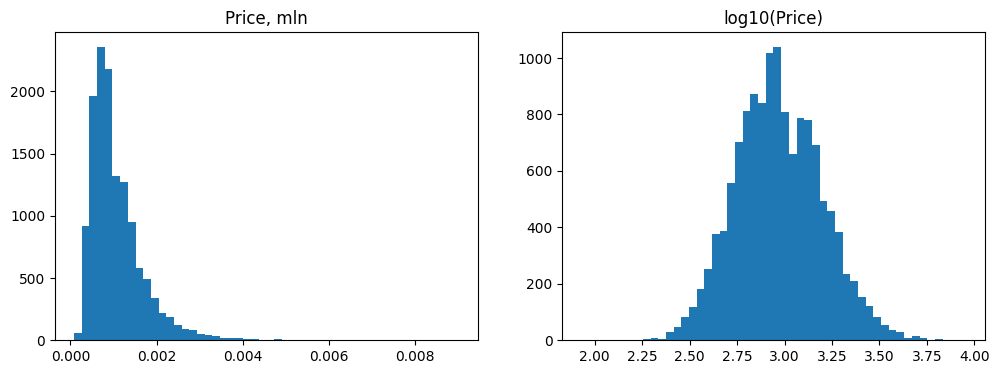


Conclusion:
- the original Price distribution is highly right-skewed with several expensive outliers,
- the log10 transformation makes the distribution much more symmetric and close to normal,
- this suggests that using log-transformed prices is more appropriate for further modeling



In [121]:
# Distribution of the 'price'
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(clean['price'] / 1e6, bins=50)
ax[0].set_title("Price, mln")
ax[1].hist(np.log10(clean['price']), bins=50)
ax[1].set_title("log10(Price)")

plt.show()

print("""
Conclusion:
- the original Price distribution is highly right-skewed with several expensive outliers,
- the log10 transformation makes the distribution much more symmetric and close to normal,
- this suggests that using log-transformed prices is more appropriate for further modeling
""")

<Figure size 800x500 with 0 Axes>

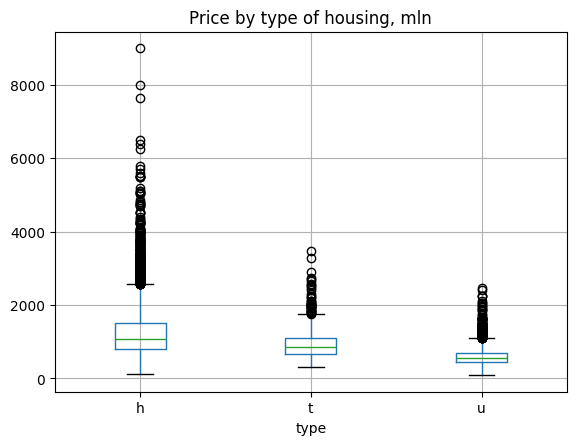


Conclusion:
- houses have the highest median prices and the greatest variability,
- townhouses are moderately priced, while units are the least expensive,
- all three property types contain outliers, with houses showing the most extreme values,
- this indicates that property type has a significant impact on price



In [122]:
# how the price dependson the type of housing
plt.figure(figsize=(8,5))
clean.boxplot(column='price', by='type')
plt.title('Price by type of housing, mln')
plt.suptitle('')

plt.show()

print("""
Conclusion:
- houses have the highest median prices and the greatest variability,
- townhouses are moderately priced, while units are the least expensive,
- all three property types contain outliers, with houses showing the most extreme values,
- this indicates that property type has a significant impact on price
""")

<Figure size 1200x500 with 0 Axes>

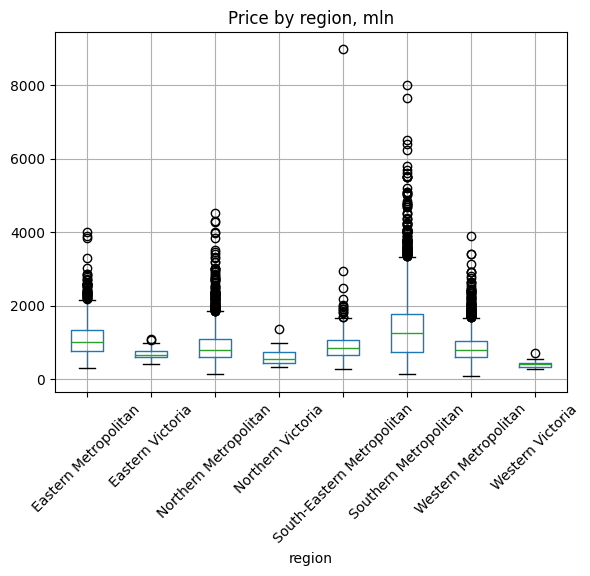


Conclusion:
- house prices differ significantly between regions,
- Southern Metropolitan has the highest median prices, while Western Victoria has the lowest,
- several regions contain expensive outliers, showing substantial price variation
- region is an important predictor of house prices



In [123]:
# how the price dependson the type of region
plt.figure(figsize=(12,5))
clean.boxplot(column='price', by='region', rot=45)
plt.title('Price by region, mln')
plt.suptitle('')

plt.show()

print("""
Conclusion:
- house prices differ significantly between regions,
- Southern Metropolitan has the highest median prices, while Western Victoria has the lowest,
- several regions contain expensive outliers, showing substantial price variation
- region is an important predictor of house prices
""")

cnt_rooms        0.499
bedroom          0.483
bathroom         0.470
year_built      -0.336
cnt_carpots      0.237
lattitude       -0.211
longtitude       0.203
distance        -0.164
postcode         0.106
build_area       0.091
propertycount   -0.042
landsize         0.023
Name: price, dtype: float64


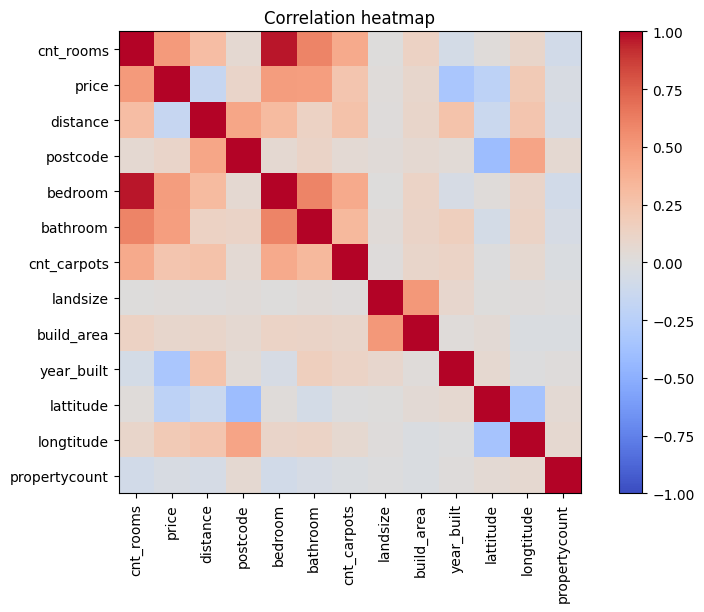


Conclusion:
- the number of rooms, bedrooms, and bathrooms has the strongest positive relationship with house price,
- most other numerical variables show weak or moderate correlations
- no feature has a very strong correlation with price, indicating that predicting house prices requires combining multiple variables.



In [124]:
# Correlation price
num = clean.select_dtypes('number')
cor_price = num.corr()['price'].drop('price')
print(cor_price.sort_values(key=abs, ascending=False).round(3))

# Correlation heatmap
plt.figure(figsize=(10, 6))
plt.imshow(num.corr(), cmap='coolwarm', vmax=1, vmin=-1)
plt.xticks(range(len(num.columns)), num.columns, rotation=90)
plt.yticks(range(len(num.columns)), num.columns)
plt.title('Correlation heatmap')
plt.colorbar()
plt.show()

print("""
Conclusion:
- the number of rooms, bedrooms, and bathrooms has the strongest positive relationship with house price,
- most other numerical variables show weak or moderate correlations
- no feature has a very strong correlation with price, indicating that predicting house prices requires combining multiple variables.
""")

In [125]:
# Search duplicate features
corr = num.corr()
corr

print()

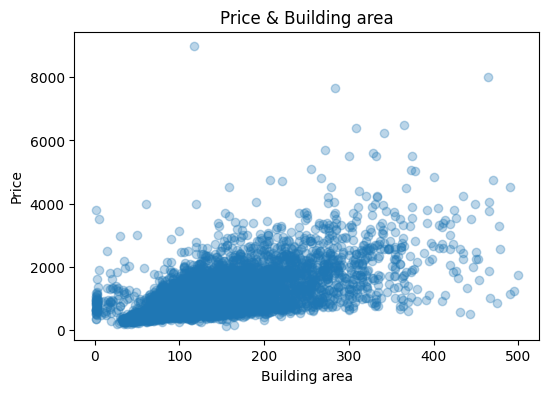


Conclusion:
- building area has a positive relationship with house price, but the association is relatively weak,
- rows with similar building areas can have very different prices, suggesting that other factors also influence house prices,
- the plot excludes buildings larger than 500 m² to improve readability.



In [126]:
#scatter plot "Price & Building area"
sc_plot_clean = clean[clean['build_area'] <= 500] # area <= 500 value of build_area reduced due high impact outliers(max = 44515)

plt.figure(figsize=(6,4))
plt.scatter(sc_plot_clean['build_area'], sc_plot_clean['price'], alpha=0.3)
plt.title('Price & Building area')
plt.xlabel('Building area')
plt.ylabel('Price')
plt.show()

print("""
Conclusion:
- building area has a positive relationship with house price, but the association is relatively weak,
- rows with similar building areas can have very different prices, suggesting that other factors also influence house prices,
- the plot excludes buildings larger than 500 m² to improve readability.
""")

## Future engineering

In [127]:
fe = clean.copy() # copy of df

# year & month of sale date
fe['sale_year'] = fe['date'].dt.year
fe['sale_month'] = fe['date'].dt.month

# age of building
fe['age'] = fe['sale_year'] - fe['year_built']
fe.loc[fe['age'] < 0, 'age'] = np.nan

# skip flags
fe["has_build_area"] = fe["build_area"].notna().astype(int)
fe["has_year_built"] = fe["year_built"].notna().astype(int)
fe["has_landsize"] = fe["landsize"].notna().astype(int)

# frequency encoding
suburb_freq = fe['suburb'].value_counts()
fe['suburb_freq'] = fe['suburb'].map(suburb_freq)

fe.head()


,suburb,address,cnt_rooms,type,price,method,seller,date,distance,postcode,bedroom,bathroom,cnt_carpots,landsize,build_area,year_built,gov_area,lattitude,longtitude,region,propertycount,sale_year,sale_month,age,has_build_area,has_year_built,has_landsize,suburb_freq
0,Abbotsford,85 Turner St,2,h,1480.0,S,Biggin,2016-12-03,2.5,3067,2,1,1,202.0,NaN,<NA>,Yarra,-37.7996,144.9984,Northern Metropolitan,4019,2016,12,<NA>,0,0,1,54
1,Abbotsford,25 Bloomburg St,2,h,1035.0,S,Biggin,2016-02-04,2.5,3067,2,1,0,156.0,79.0,1900,Yarra,-37.8079,144.9934,Northern Metropolitan,4019,2016,2,116,1,1,1,54
2,Abbotsford,5 Charles St,3,h,1465.0,SP,Biggin,2017-03-04,2.5,3067,3,2,0,134.0,150.0,1900,Yarra,-37.8093,144.9944,Northern Metropolitan,4019,2017,3,117,1,1,1,54
3,Abbotsford,40 Federation La,3,h,850.0,PI,Biggin,2017-03-04,2.5,3067,3,2,1,94.0,NaN,<NA>,Yarra,-37.7969,144.9969,Northern Metropolitan,4019,2017,3,<NA>,0,0,1,54
4,Abbotsford,55a Park St,4,h,1600.0,VB,Nelson,2016-06-04,2.5,3067,3,1,2,120.0,142.0,2014,Yarra,-37.8072,144.9941,Northern Metropolitan,4019,2016,6,2,1,1,1,54


In [128]:
# drop "noisy" columns
fe = fe.drop(columns=[
    'suburb',
    'address',
    'seller',
    'date',
    'bedroom',
    'year_built',
    'build_area'
])

In [129]:
fe.head()

,cnt_rooms,type,price,method,distance,postcode,bathroom,cnt_carpots,landsize,gov_area,lattitude,longtitude,region,propertycount,sale_year,sale_month,age,has_build_area,has_year_built,has_landsize,suburb_freq
0,2,h,1480.0,S,2.5,3067,1,1,202.0,Yarra,-37.7996,144.9984,Northern Metropolitan,4019,2016,12,<NA>,0,0,1,54
1,2,h,1035.0,S,2.5,3067,1,0,156.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019,2016,2,116,1,1,1,54
2,3,h,1465.0,SP,2.5,3067,2,0,134.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019,2017,3,117,1,1,1,54
3,3,h,850.0,PI,2.5,3067,2,1,94.0,Yarra,-37.7969,144.9969,Northern Metropolitan,4019,2017,3,<NA>,0,0,1,54
4,4,h,1600.0,VB,2.5,3067,1,2,120.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019,2016,6,2,1,1,1,54


## Data Preparation for Modeling

In [130]:
#define features and target
y = fe['price']
X = fe.drop(columns=['price'])

# categorial / number
num_cols = [c for c in X.columns if c not in cat_cols]
cat_cols = ['type', 'method', 'gov_area', 'region']


In [131]:
# ColumnTransformer
preprocess = ColumnTransformer([
    ("num", SimpleImputer(strategy='median'), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy='most_frequent')),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols)
])


In [132]:
# data -> train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)
print("Train:", X_train.shape[0],"Test:", )

Train: 10686 Test:


In [133]:
# create evaluate function
def evaluate(model, name):
  pipe = Pipeline([
      ('prep', preprocess),
      ('model', model)
  ])

  pipe.fit(X_train, y_train)
  pred = pipe.predict(X_test)

  mae = mean_absolute_error(y_test, pred)
  rmse = np.sqrt(mean_squared_error(y_test, pred))
  r2 = r2_score(y_test, pred)

  print(f"\n{name}")
  print(f"\nMAE: {mae:.3f}")
  print(f"\nRMSE: {rmse:.3f}")
  print(f"\nR2: {r2:.3f}")

  return {
      'name': name,
      'model': pipe,
      'pred': pred,
      'mae': mae,
      'rmse': rmse,
      'r2': r2
  }

In [134]:
# Evaluate all models
dummy = evaluate(DummyRegressor(strategy='mean'), "Dummy Regressor")
linear = evaluate(LinearRegression(),'Linear Regression')
forest = evaluate(RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE), 'Random Forest Regressor')
xgboost = evaluate(XGBRegressor(n_estimators=300, learning_rate=0.5, max_depth=4, random_state=RANDOM_STATE, eval_metric='logloss'), 'XGBoost')


Dummy Regressor

MAE: 457.631

RMSE: 633.151

R2: -0.000

Linear Regression

MAE: 256.360

RMSE: 377.121

R2: 0.645

Random Forest Regressor

MAE: 168.009

RMSE: 276.556

R2: 0.809

XGBoost

MAE: 176.418

RMSE: 281.235

R2: 0.803


In [135]:
# Results dataframe
results = pd.DataFrame([
    dummy,
    linear,
    forest,
    xgboost
])

results

,name,model,pred,mae,rmse,r2
0,Dummy Regressor,"(ColumnTransformer(transformers=[('num', Simpl...","[1072.0635116039678, 1072.0635116039678, 1072....",457.631319,633.151166,-0.000081
1,Linear Regression,"(ColumnTransformer(transformers=[('num', Simpl...","[1514.0632008506218, 1023.3973387639853, 1846....",256.359621,377.121425,0.645201
2,Random Forest Regressor,"(ColumnTransformer(transformers=[('num', Simpl...","[1556.8209399999998, 1086.471, 1787.6765, 995....",168.008798,276.555723,0.809197
3,XGBoost,"(ColumnTransformer(transformers=[('num', Simpl...","[1555.9415, 939.37823, 1508.0936, 711.303, 209...",176.418250,281.234770,0.802686


<Axes: title={'center': 'Difference of model`s indicators'}>

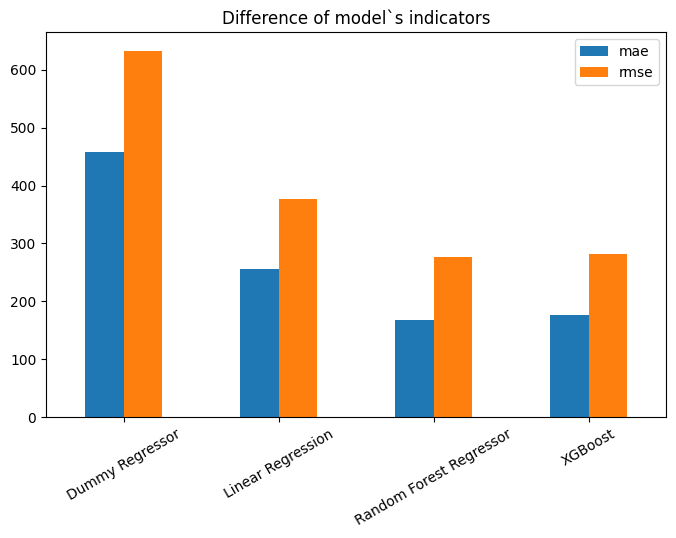

In [136]:
results.plot(
    x='name',
    y=['mae', 'rmse'],
    kind='bar',
    figsize=(8,5),
    rot=30,
    xlabel='',
    title='Difference of model`s indicators'
)

<Axes: title={'center': 'Difference of model`s r2'}>

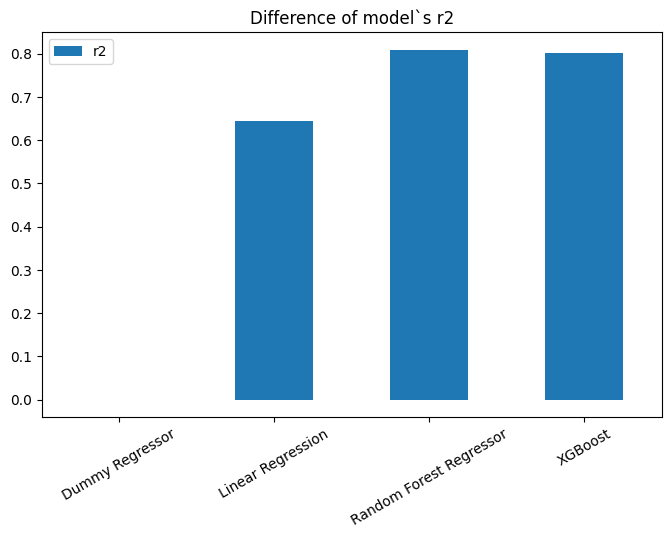

In [137]:
# R2 for all models
results.plot(
    x='name',
    y='r2',
    kind='bar',
    figsize=(8,5),
    rot=30,
    xlabel='',
    title='Difference of model`s r2'
)


In [138]:
# Feature importance from XGBoost
best_model = xgboost["model"]
feature_names = best_model.named_steps["prep"].get_feature_names_out()

importance = best_model.named_steps["model"].feature_importances_

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(10)

,Feature,Importance
62,cat__region_Southern Metropolitan,0.550682
18,cat__type_u,0.093300
57,cat__region_Eastern Metropolitan,0.054599
0,num__cnt_rooms,0.041106
16,cat__type_h,0.032707
3,num__bathroom,0.024537
25,cat__gov_area_Bayside,0.018330
1,num__distance,0.017811
50,cat__gov_area_Stonnington,0.013515
36,cat__gov_area_Kingston,0.010546


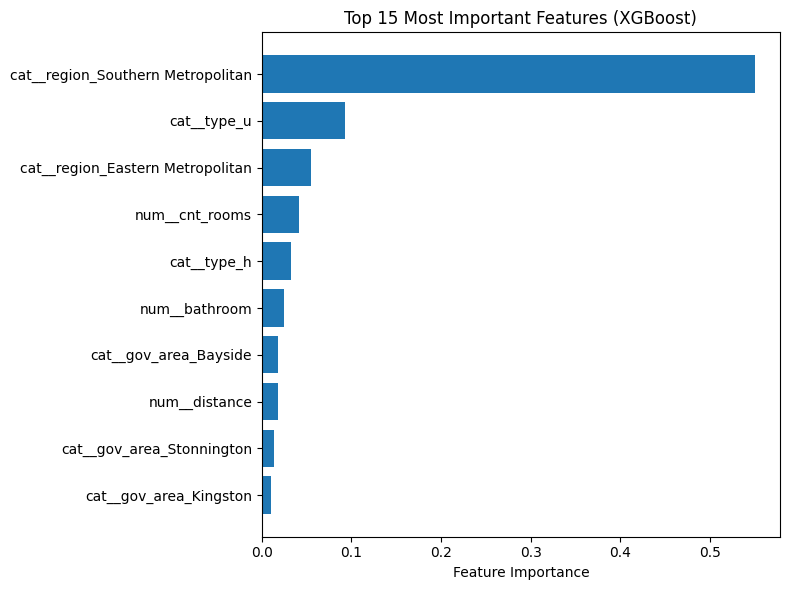

In [139]:

top = importance_df.head(10).sort_values("Importance")

plt.figure(figsize=(8,6))

plt.barh(top["Feature"], top["Importance"])

plt.xlabel("Feature Importance")
plt.title("Top 15 Most Important Features (XGBoost)")

plt.tight_layout()
plt.show()

In [140]:
# Price forecast for example
example = X_test.iloc[[0]]
new_price = xgboost['model'].predict(example)

print(f"Predicted price: {new_price[0]:.1F}")
print(f"Real price: {y_test.iloc[0]}")

Predicted price: 1555.9
Real price: 1450.0
